# Loan Approval Prediction using Machine Learning

## Problem Statement
Developd a machine learning model to predict whether a loan application will be approved based on applicant financial and personal details.

## Importing Libraries

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [72]:
df = pd.read_csv("loan_approval_dataset.csv")

In [73]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## DataSet Overview

In [74]:
df.shape

(4269, 13)

In [75]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [77]:
df.dtypes

loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

In [78]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [79]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## Data Cleaning

In [80]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


## Target Variable Analysis

In [81]:
df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

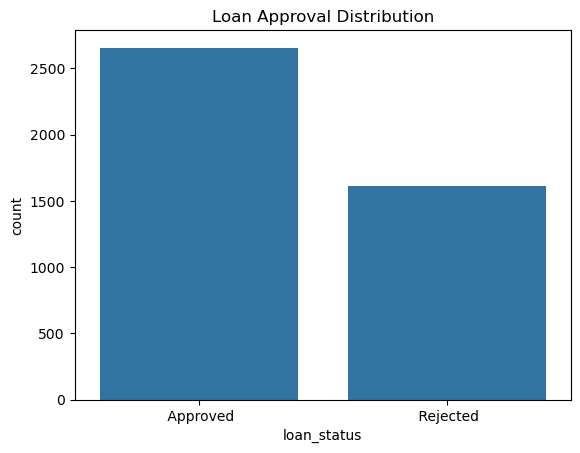

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="loan_status", data=df)
plt.title("Loan Approval Distribution")
plt.show()

Identifying Encode Categorical Variables

## Feature Selection

In [94]:
X = df.drop(["loan_id", "loan_status"], axis=1)
y = df["loan_status"]

In [96]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [97]:
X.select_dtypes(include="object").columns

Index(['education', 'self_employed'], dtype='object')

## Label Encoding

In [98]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [99]:
X["education"] = le.fit_transform(X["education"])
X["self_employed"] = le.fit_transform(X["self_employed"])

In [100]:
y = le.fit_transform(y)

In [101]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000


## Train-Test Split

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(
X,
y,
test_size=0.20,
random_state=42
)

In [106]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(3415, 11)
(854, 11)
(3415,)
(854,)


In [108]:
print(y_train[:5])

[0 0 0 0 1]


Model

## Build Model

In [109]:
from sklearn.ensemble import RandomForestClassifier

In [110]:
rf_model = RandomForestClassifier(random_state=42)

## Train Model

In [111]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Prediction

In [112]:
y_pred = rf_model.predict(X_test)

## Model Evaluation

In [113]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [114]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.977751756440281


In [115]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[529   7]
 [ 12 306]]


In [116]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



## Feature Importance

In [117]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                     Feature  Importance
6                cibil_score    0.809939
5                  loan_term    0.064499
4                loan_amount    0.028938
7   residential_assets_value    0.018168
3               income_annum    0.018060
9        luxury_assets_value    0.017745
10          bank_asset_value    0.015261
8    commercial_assets_value    0.014440
0           no_of_dependents    0.008385
2              self_employed    0.002473
1                  education    0.002093


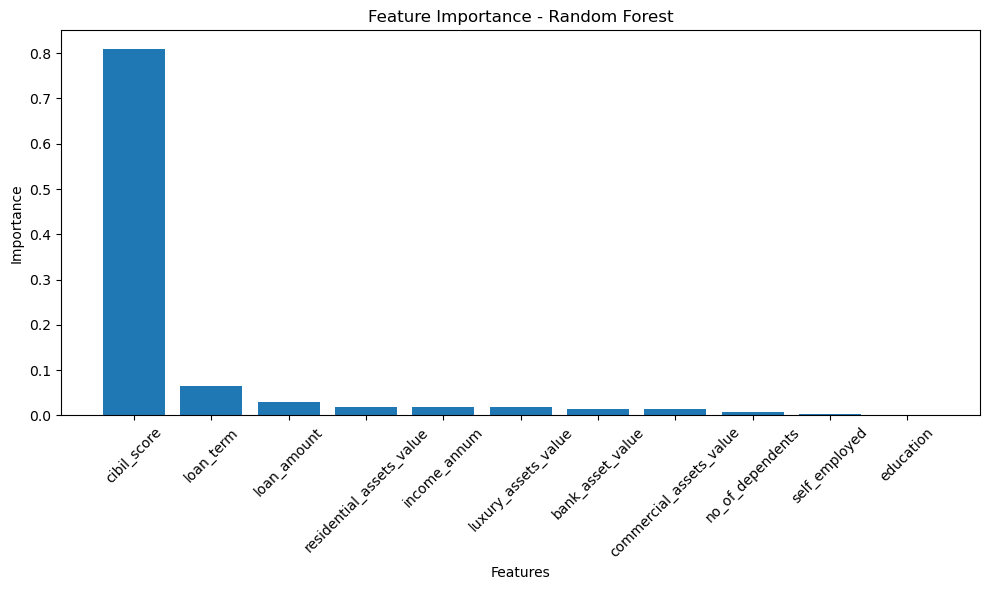

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")

plt.tight_layout()
plt.show()

## Save Model

In [119]:
import joblib

joblib.dump(rf_model, "loan_prediction_model.pkl")

['loan_prediction_model.pkl']

## Load Model

In [120]:
loaded_model = joblib.load("loan_prediction_model.pkl")

loaded_model.predict(X_test[:5])

array([1, 0, 1, 0, 0])

## Predict on New Excel File

In [121]:
import pandas as pd
import joblib

# Load new applicant data
new_data = pd.read_excel("new_applicants.xlsx")

# Apply the same preprocessing
new_data['education'] = new_data['education'].map({'Graduate': 1, 'Not Graduate': 0})
new_data['self_employed'] = new_data['self_employed'].map({'Yes': 1, 'No': 0})

# Load the saved model
loaded_model = joblib.load("loan_prediction_model.pkl")

# Make predictions
predictions = loaded_model.predict(new_data)

# Add predictions to the DataFrame
new_data['Prediction'] = predictions

# Save the results
new_data.to_excel("loan_predictions.xlsx", index=False)

print("Predictions saved successfully!")

Predictions saved successfully!


In [122]:
print(predictions)

[1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 1 1 1 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 1 0 1 0 1 1
 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 1 0
 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0 1 0 1 0 1 1 1
 0 0]


## Project Conclusion

The Random Forest Classifier achieved an accuracy of 97.78% in predicting loan approvals. Feature importance analysis showed that CIBIL Score was the most influential factor, followed by loan term and loan amount. The trained model was successfully saved and later used to predict loan approvals for new applicants from an external Excel file.